In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
sales_data = pd.read_csv("../data/sales_transactions.csv")

In [72]:
sales_data.head()

,order_id,branch,item_name,quantity,price,revenue,order_date,order_hour,category,payment_method,day_of_week,is_weekend,meal_period,order_channel
0,1,Leeds Selfridges,Salmon Nigiri,1,5.50,5.5,2025-09-01,19,Sushi,Card,Monday,False,Dinner,Uber Eats
1,2,London Selfridges,Chicken Yakitori,4,6.95,27.8,2025-06-08,18,Sides,Card,Sunday,True,Dinner,Takeaway
2,3,Manchester Selfridges,Miso Soup,4,3.50,14.0,2025-09-30,18,Drinks,Cash,Tuesday,False,Dinner,Takeaway
3,4,Manchester Selfridges,Asahi Beer,2,5.95,11.9,2025-06-11,17,Alcohol,Card,Wednesday,False,Dinner,Dine In
4,5,London Selfridges,Chicken Katsu Curry,3,13.50,40.5,2025-07-29,15,Curry,Cash,Tuesday,False,Lunch,Uber Eats


In [73]:
sales_data.shape

(10000, 14)

In [74]:
sales_data.isnull().sum()

order_id          0
branch            0
item_name         0
quantity          0
price             0
revenue           0
order_date        0
order_hour        0
category          0
payment_method    0
day_of_week       0
is_weekend        0
meal_period       0
order_channel     0
dtype: int64

In [75]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  int64  
 1   branch          10000 non-null  object 
 2   item_name       10000 non-null  object 
 3   quantity        10000 non-null  int64  
 4   price           10000 non-null  float64
 5   revenue         10000 non-null  float64
 6   order_date      10000 non-null  object 
 7   order_hour      10000 non-null  int64  
 8   category        10000 non-null  object 
 9   payment_method  10000 non-null  object 
 10  day_of_week     10000 non-null  object 
 11  is_weekend      10000 non-null  bool   
 12  meal_period     10000 non-null  object 
 13  order_channel   10000 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(8)
memory usage: 1.0+ MB


In [76]:
sales_data["order_date"] = pd.to_datetime(sales_data["order_date"])

sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        10000 non-null  int64         
 1   branch          10000 non-null  object        
 2   item_name       10000 non-null  object        
 3   quantity        10000 non-null  int64         
 4   price           10000 non-null  float64       
 5   revenue         10000 non-null  float64       
 6   order_date      10000 non-null  datetime64[ns]
 7   order_hour      10000 non-null  int64         
 8   category        10000 non-null  object        
 9   payment_method  10000 non-null  object        
 10  day_of_week     10000 non-null  object        
 11  is_weekend      10000 non-null  bool          
 12  meal_period     10000 non-null  object        
 13  order_channel   10000 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(2), int64(3), ob

In [77]:
sales_data.groupby("branch")["revenue"].sum().round(2).sort_values(ascending=False)

branch
Birmingham Selfridges    47968.50
Manchester Selfridges    45537.25
Leeds Selfridges         45123.75
London Selfridges        43905.20
Name: revenue, dtype: float64

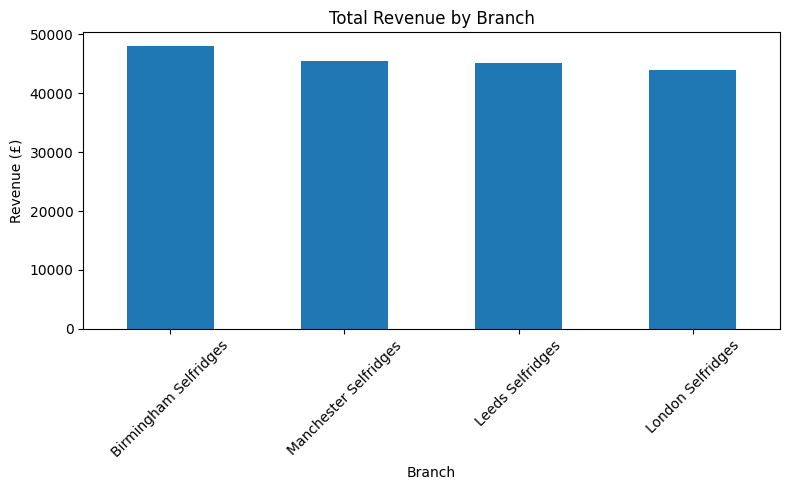

In [78]:
branch_revenue = (sales_data.groupby("branch")["revenue"]
                .sum()
                .round(2)
                .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
branch_revenue.plot(kind="bar")
plt.title("Total Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
category_revenue = (
    sales_data.groupby("category")["revenue"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

print(category_revenue)

category
Sushi        39842.0
Ramen        23171.0
Curry        23089.5
Sides        22801.2
Hot Food     19251.3
Dessert      19229.5
Drinks       12140.5
Rice Bowl    11888.5
Alcohol      11121.2
Name: revenue, dtype: float64


In [80]:
category_quantity = (
    sales_data.groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(category_quantity)

category
Sushi        6884
Sides        3480
Dessert      3355
Drinks       3273
Hot Food     2470
Alcohol      1668
Curry        1653
Ramen        1598
Rice Bowl     767
Name: quantity, dtype: int64


In [81]:
sales_data.groupby("is_weekend")["revenue"].sum().round(2)

is_weekend
False    131294.15
True      51240.55
Name: revenue, dtype: float64

In [82]:
sales_data.groupby("is_weekend")["order_date"].nunique()

is_weekend
False    261
True     104
Name: order_date, dtype: int64

In [83]:
weekend_analysis = (
    sales_data.groupby("is_weekend")
    .agg(
        total_revenue=("revenue", "sum"),
        days=("order_date", "nunique")
    )
)

weekend_analysis["revenue_per_day"] = (
    weekend_analysis["total_revenue"]
    / weekend_analysis["days"]
).round(2)

weekend_analysis

,total_revenue,days,revenue_per_day
is_weekend,,,
False,131294.15,261,503.04
True,51240.55,104,492.70


In [84]:
meal_period_revenue = (
    sales_data.groupby("meal_period")["revenue"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

print(meal_period_revenue)

meal_period
Dinner        88768.65
Lunch         84095.75
Morning        5473.60
Late Night     4196.70
Name: revenue, dtype: float64


In [85]:
sales_data.groupby("meal_period")["order_id"].count().sort_values(ascending=False)

meal_period
Dinner        4803
Lunch         4683
Morning        306
Late Night     208
Name: order_id, dtype: int64

In [86]:
meal_period_aov = (
    sales_data.groupby("meal_period")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("order_id", "count")
    )
)

meal_period_aov["avg_order_value"] = (
    meal_period_aov["total_revenue"]
    / meal_period_aov["total_orders"]
).round(2)

meal_period_aov.sort_values(
    "avg_order_value",
    ascending=False
)

,total_revenue,total_orders,avg_order_value
meal_period,,,
Late Night,4196.70,208,20.18
Dinner,88768.65,4803,18.48
Lunch,84095.75,4683,17.96
Morning,5473.60,306,17.89


In [87]:
channel_revenue = (
    sales_data.groupby("order_channel")["revenue"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

print(channel_revenue)

order_channel
Dine In      91073.40
Deliveroo    35028.75
Takeaway     28959.05
Uber Eats    27473.50
Name: revenue, dtype: float64


In [88]:
sales_data.groupby("order_channel")["order_id"].count().sort_values(ascending=False)

order_channel
Dine In      4999
Deliveroo    1908
Takeaway     1581
Uber Eats    1512
Name: order_id, dtype: int64

In [89]:
channel_aov = (
    sales_data.groupby("order_channel")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("order_id", "count")
    )
)

channel_aov["avg_order_value"] = (
    channel_aov["total_revenue"]
    / channel_aov["total_orders"]
).round(2)

channel_aov.sort_values(
    "avg_order_value",
    ascending=False
)

,total_revenue,total_orders,avg_order_value
order_channel,,,
Deliveroo,35028.75,1908,18.36
Takeaway,28959.05,1581,18.32
Dine In,91073.40,4999,18.22
Uber Eats,27473.50,1512,18.17


In [90]:
payment_revenue = (
    sales_data.groupby("payment_method")["revenue"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

print(payment_revenue)

payment_method
Card         121766.55
Cash          40321.20
Gift Card     20446.95
Name: revenue, dtype: float64


In [91]:
top_products = (
    sales_data.groupby("item_name")["revenue"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

item_name
Beef Teriyaki Donburi        11888.50
Chicken Katsu Curry          11866.50
Chicken Dashi Ramen          11643.50
Chashu Chicken Ramen         11527.50
Prawn Katsu Curry            11223.00
Korean Fried Chicken          6717.75
Chicken Katsu Sushi Sando     6420.00
Chicken Gyoza                 6180.00
Chicken Yakitori              6157.70
Japanese Fried Chicken        6113.55
Name: revenue, dtype: float64


In [92]:
top_quantity = (
    sales_data.groupby("item_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_quantity)

item_name
Crunchy California Roll    931
YO! Fries                  919
Salmon Maki                917
Strawberry Little Moons    901
Asahi Beer                 896
Miso Caramel Brownie       894
Chicken Yakitori           886
Chicken Katsu Curry        879
Salmon Nigiri              863
YO! Roll                   862
Name: quantity, dtype: int64


In [101]:
sales_data["month_number"] = sales_data["order_date"].dt.month

monthly_revenue = (
    sales_data.groupby("month_number")["revenue"]
    .sum()
    .round(2)
)

print(monthly_revenue)

month_number
1     15190.50
2     13725.75
3     14131.95
4     15847.50
5     15614.65
6     15084.35
7     15482.80
8     16119.65
9     14459.45
10    16018.85
11    15627.90
12    15231.35
Name: revenue, dtype: float64


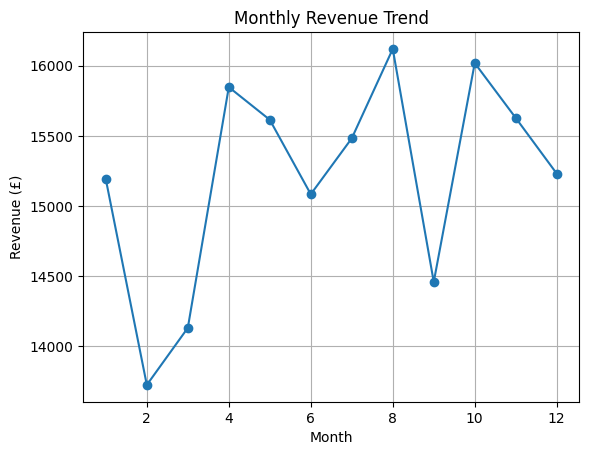

In [100]:
monthly_revenue.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)

plt.show()
